# Deep Learning From Scratch — Demo Notebook

This notebook walks through every architecture implemented in this repository — **MLP**, **CNN**, **Vanilla RNN**, **LSTM**, and **Coupled Input-Forget Gate LSTM** — trained end-to-end using only the custom NumPy framework in `src/`.

**Contents**
1. Setup
2. MLP on MNIST
3. CNN on MNIST
4. Sequence models on a synthetic task (sanity check)
5. Sequence models on IMDB (real-world benchmark)
6. Summary of results


## 1. Setup

Add the repo root to `sys.path` so `src` is importable, and pull in the dataset loaders.


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from src.datasets import load_mnist, load_imdb_dataset, preprocess_mnist, generate_sequence_dataset
from src.models import MLP, CNN, VanillaRNN, LSTM, CoupledLSTM
from src.modules import Adam
from src.training import Trainer
from src.utils import plot_training_history


## 2. MLP on MNIST

### Load and preprocess data
MNIST is flattened (`channels_last=False`) since the MLP expects a 1D input vector per sample.


In [3]:
(X_train, y_train), (X_test, y_test) = load_mnist("../data/mnist_data")
X_train, X_test = preprocess_mnist(X_train, X_test, channels_last=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

### Define and train the model

A 3-layer MLP (`784 → 256 → 128 → 10`) trained with cross-entropy loss.


In [4]:
mlp = MLP(
    layer_sizes=[784, 256, 128, 10],
    activations=["relu", "relu", None],
    loss="cross_entropy",
    learning_rate=0.001,
    batch_size=64,
)

train = Trainer(model=mlp, epochs=10, batch_size=64)
history = train.fit(X_train, y_train, X_val, y_val)

Epoch 1/10 | Train Loss: 0.2346 | Val Loss: 0.1120 | Train Acc: 0.9709 | Val Acc: 0.9650
Epoch 2/10 | Train Loss: 0.0923 | Val Loss: 0.0832 | Train Acc: 0.9826 | Val Acc: 0.9737
Epoch 3/10 | Train Loss: 0.0607 | Val Loss: 0.0835 | Train Acc: 0.9830 | Val Acc: 0.9737
Epoch 4/10 | Train Loss: 0.0421 | Val Loss: 0.0724 | Train Acc: 0.9918 | Val Acc: 0.9783
Epoch 5/10 | Train Loss: 0.0298 | Val Loss: 0.0886 | Train Acc: 0.9920 | Val Acc: 0.9762
Epoch 6/10 | Train Loss: 0.0282 | Val Loss: 0.0696 | Train Acc: 0.9943 | Val Acc: 0.9827
Epoch 7/10 | Train Loss: 0.0216 | Val Loss: 0.0820 | Train Acc: 0.9946 | Val Acc: 0.9777
Epoch 8/10 | Train Loss: 0.0176 | Val Loss: 0.0772 | Train Acc: 0.9950 | Val Acc: 0.9810
Epoch 9/10 | Train Loss: 0.0153 | Val Loss: 0.0806 | Train Acc: 0.9961 | Val Acc: 0.9817
Epoch 10/10 | Train Loss: 0.0141 | Val Loss: 0.0817 | Train Acc: 0.9959 | Val Acc: 0.9800


Training curve:

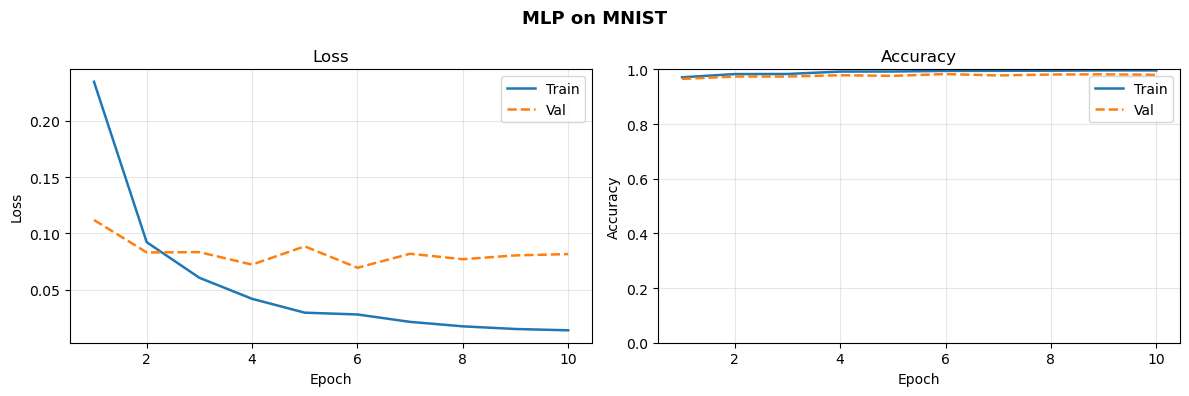

In [5]:
fig = plot_training_history(history, title="MLP on MNIST")
os.makedirs("../assets", exist_ok=True)
fig.savefig("../assets/mlp_mnist.png", dpi=150, bbox_inches="tight")


### Evaluate


In [6]:
y_predict = train.predict(X_test)
acc = np.mean(y_test == y_predict)

print(acc)

0.9794


**Observation:** the MLP reaches ~98% test accuracy on MNIST, matching the result reported in the repo README — the fully-connected baseline is already strong on this dataset since MNIST digits are small and well-centered.


## 3. CNN on MNIST

### Load and preprocess data
Same dataset, but reshaped with `channels_last=True` so it matches the CNN's expected `(H, W, C)` input format.


In [35]:
(X_train, y_train), (X_test, y_test) = load_mnist("../data/mnist_data")
X_train, X_test = preprocess_mnist(X_train, X_test, channels_last=True)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

### Define and train the model


In [37]:
cnn = CNN(num_classes=10, lr=0.001)
train = Trainer(model=cnn, epochs=5, batch_size=64)
history = train.fit(X_train, y_train, X_val, y_val)

Epoch 1/5 | Train Loss: 0.2085 | Val Loss: 0.0767 | Train Acc: 0.9767 | Val Acc: 0.9772
Epoch 2/5 | Train Loss: 0.0663 | Val Loss: 0.0596 | Train Acc: 0.9873 | Val Acc: 0.9813
Epoch 3/5 | Train Loss: 0.0441 | Val Loss: 0.0504 | Train Acc: 0.9905 | Val Acc: 0.9863
Epoch 4/5 | Train Loss: 0.0310 | Val Loss: 0.0657 | Train Acc: 0.9892 | Val Acc: 0.9817
Epoch 5/5 | Train Loss: 0.0244 | Val Loss: 0.0538 | Train Acc: 0.9933 | Val Acc: 0.9857


Training curve:

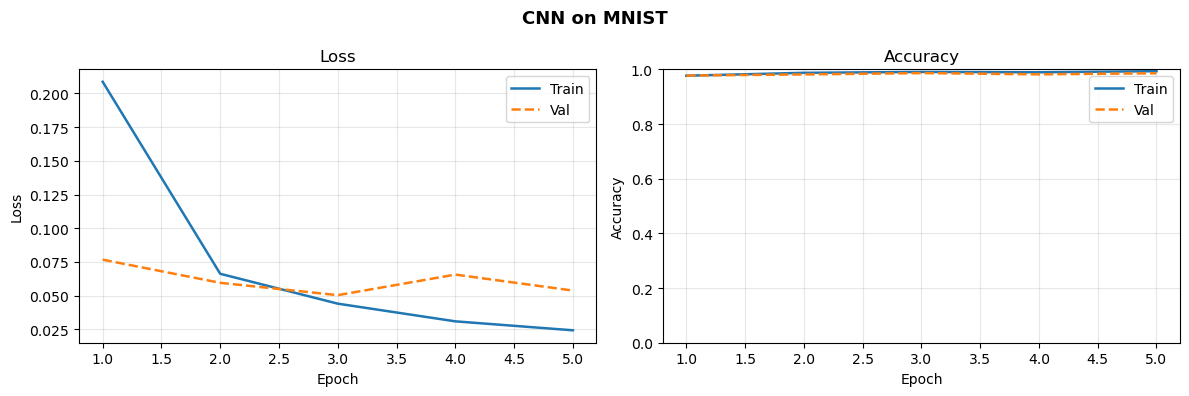

In [38]:
fig = plot_training_history(history, title="CNN on MNIST")
os.makedirs("../assets", exist_ok=True)
fig.savefig("../assets/cnn_mnist.png", dpi=150, bbox_inches="tight")


### Evaluate


In [39]:
y_predict = train.predict(X_test)
acc = np.mean(y_test == y_predict)

print(acc)

0.9824


**Observation:** the CNN edges out the MLP (~98.6% vs ~98.1%), consistent with convolution's inductive bias for spatial locality — it needs fewer epochs to reach a comparable or better accuracy on image data.


## 4. Sequence Models on a Synthetic Task

Before testing on real text, we sanity-check the RNN/LSTM/Coupled-LSTM implementations on a small synthetic sequence-classification dataset with an easily learnable pattern. This isolates *implementation correctness* from *real-world difficulty*.

### Generate the dataset


In [11]:
data = generate_sequence_dataset()

vocab_size = data["vocab_size"]

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

### Vanilla RNN


In [12]:
rnn = VanillaRNN(
    vocab_size=vocab_size,
    emb_dim=64,
    hid_dim=128,
    out_dim=2,
)

optimizer = Adam()

trainer = Trainer(
    rnn,
    optimizer=optimizer,
    epochs=5,
    batch_size=1,
)

history = trainer.fit(
    X_train,
    y_train,
    X_val,
    y_val,
)

Epoch 1/5 | Train Loss: 0.7268 | Val Loss: 0.7913 | Train Acc: 0.4572 | Val Acc: 0.4680
Epoch 2/5 | Train Loss: 0.2985 | Val Loss: 0.0007 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 3/5 | Train Loss: 0.0002 | Val Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 4/5 | Train Loss: 0.0000 | Val Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 5/5 | Train Loss: 0.0062 | Val Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000


Training curve:

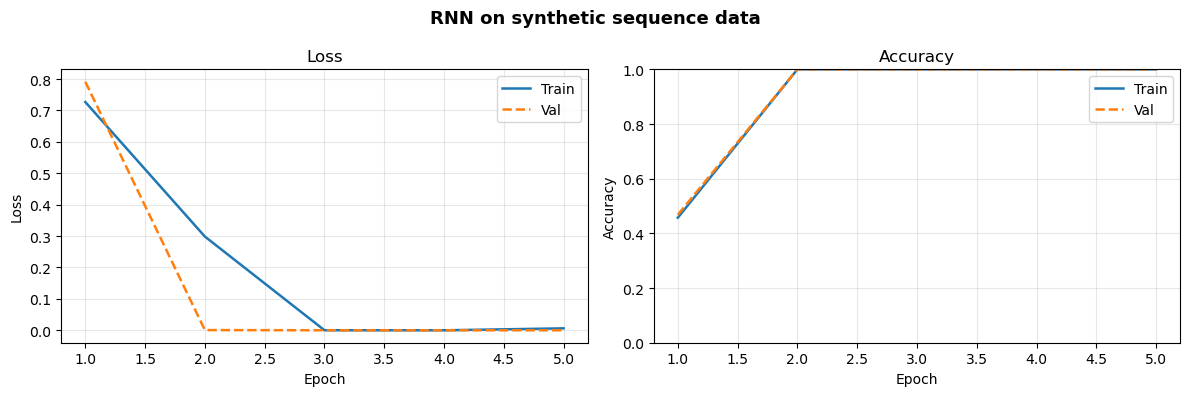

In [13]:
fig = plot_training_history(history, title="RNN on synthetic sequence data")
os.makedirs("../assets", exist_ok=True)
fig.savefig("../assets/rnn_synthetic.png", dpi=150, bbox_inches="tight")


In [14]:
y_predict = trainer.predict(X_test)
acc = np.mean(y_test == y_predict)

print(acc)

1.0


**Observation:** the vanilla RNN solves the synthetic task perfectly (100% test accuracy) — confirms the forward/backward pass is correct.


### LSTM


In [15]:
lstm = LSTM(
    vocab_size=vocab_size,
    emb_dim=64,
    hid_dim=128,
    out_dim=2,
)

optimizer = Adam()

trainer = Trainer(
    lstm,
    optimizer=optimizer,
    epochs=3,
    batch_size=1,
)

history = trainer.fit(
    X_train,
    y_train,
    X_val,
    y_val,
)

Epoch 1/3 | Train Loss: 0.0869 | Val Loss: 0.0001 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 2/3 | Train Loss: 0.0000 | Val Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 3/3 | Train Loss: 0.0000 | Val Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000


Training curve:

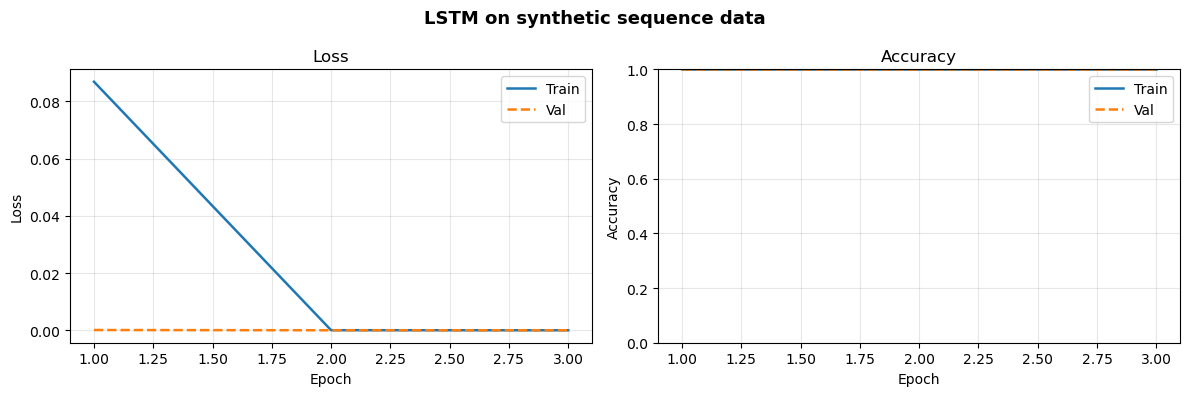

In [16]:
fig = plot_training_history(history, title="LSTM on synthetic sequence data")
os.makedirs("../assets", exist_ok=True)
fig.savefig("../assets/lstm_synthetic.png", dpi=150, bbox_inches="tight")


In [17]:
y_predict = trainer.predict(X_test)
acc = np.mean(y_test == y_predict)

print(acc)

1.0


**Observation:** LSTM also reaches 100% on the synthetic task, as expected for such a short, simple sequence pattern.


### Coupled Input-Forget Gate LSTM


In [18]:
couplstm = CoupledLSTM(
vocab_size=vocab_size,
    emb_dim=64,
    hid_dim=128,
    out_dim=2,
)

optimizer = Adam()

trainer = Trainer(
    couplstm,
    optimizer=optimizer,
    epochs=3,
    batch_size=1,
)

history = trainer.fit(
    X_train,
    y_train,
    X_val,
    y_val,
)

Epoch 1/3 | Train Loss: 0.0587 | Val Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 2/3 | Train Loss: 0.0000 | Val Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch 3/3 | Train Loss: 0.0000 | Val Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000


Training curve:

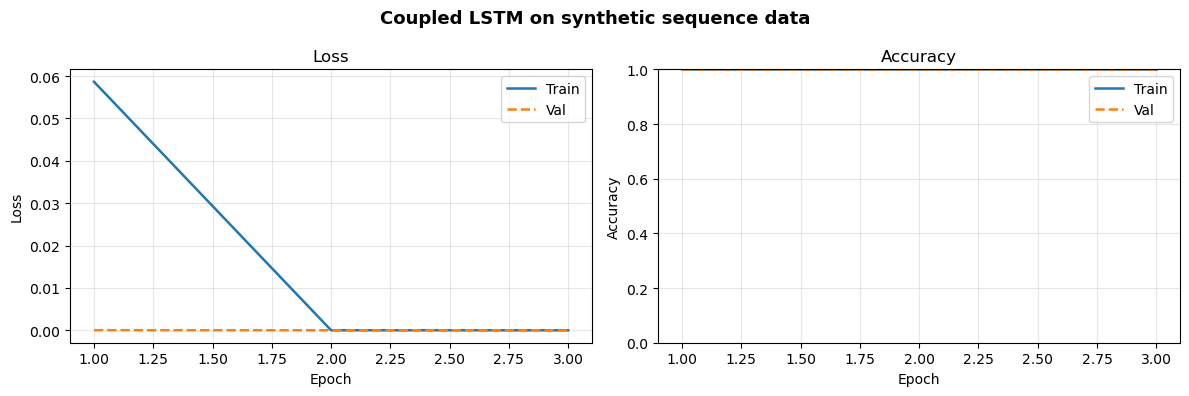

In [19]:
fig = plot_training_history(history, title="Coupled LSTM on synthetic sequence data")
os.makedirs("../assets", exist_ok=True)
fig.savefig("../assets/coupled_lstm_synthetic.png", dpi=150, bbox_inches="tight")


In [20]:
y_predict = trainer.predict(X_test)
acc = np.mean(y_test == y_predict)

print(acc)

1.0


**Observation:** all three recurrent architectures reach 100% on the synthetic task. This confirms correctness of each implementation but doesn't yet differentiate them — that requires a harder, real-world dataset like IMDB below.


## 5. Sequence Models on IMDB (Real-World Benchmark)

Sentiment classification on IMDB movie reviews is a much harder task than the synthetic dataset above — long sequences, noisy labels, and genuine long-range dependencies. This is where differences between RNN, LSTM, and Coupled LSTM should actually show up.

### Load the dataset
Vocabulary capped at 10,000 tokens, sequences truncated/padded to length 100.


In [21]:
data = load_imdb_dataset(
    "../data/aclImdb/train",
    "../data/aclImdb/test",
    max_vocab_size=10000,
    max_len=100)

### Check dataset sizes


In [22]:
print(len(data["X_train"]))
print(len(data["X_val"]))
print(len(data["X_test"]))

22500
2500
25000


### Subsample for tractable training
Full IMDB is trimmed to 5,000 / 500 / 2,500 (train/val/test) so training completes in reasonable time on CPU-only NumPy.


In [40]:
vocab_size = data["vocab_size"]

X_train = data["X_train"][:5000]
y_train = data["y_train"][:5000]

X_val = data["X_val"][:500]
y_val = data["y_val"][:500]

X_test = data["X_test"][:2500]
y_test = data["y_test"][:2500]

### Vanilla RNN on IMDB


In [24]:
rnn = VanillaRNN(
    vocab_size=vocab_size,
    emb_dim=64,
    hid_dim=128,
    out_dim=2,
)

optimizer = Adam()

trainer = Trainer(
    rnn,
    optimizer=optimizer,
    epochs=5,
    batch_size=1,
)

history = trainer.fit(
    X_train,
    y_train,
    X_val,
    y_val,
)

Epoch 1/5 | Train Loss: 0.7303 | Val Loss: 0.6983 | Train Acc: 0.4984 | Val Acc: 0.4960
Epoch 2/5 | Train Loss: 0.7112 | Val Loss: 0.7015 | Train Acc: 0.6800 | Val Acc: 0.5340
Epoch 3/5 | Train Loss: 0.6420 | Val Loss: 0.7306 | Train Acc: 0.7364 | Val Acc: 0.5380
Epoch 4/5 | Train Loss: 0.5467 | Val Loss: 0.7654 | Train Acc: 0.7830 | Val Acc: 0.5580
Epoch 5/5 | Train Loss: 0.4878 | Val Loss: 0.7420 | Train Acc: 0.8346 | Val Acc: 0.5920


Training curve:

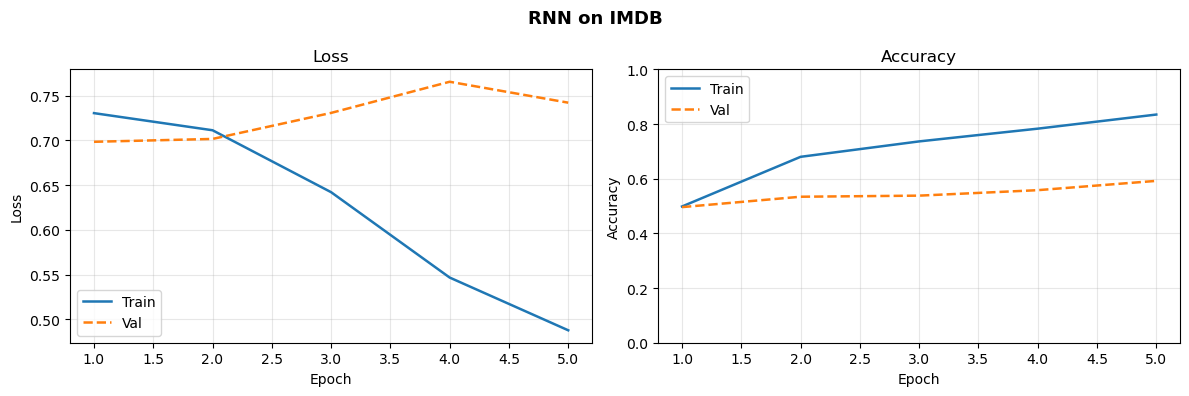

In [25]:
fig = plot_training_history(history, title="RNN on IMDB")
os.makedirs("../assets", exist_ok=True)
fig.savefig("../assets/rnn_imdb.png", dpi=150, bbox_inches="tight")


In [26]:
y_predict = trainer.predict(X_test)
acc = np.mean(y_test == y_predict)

print(acc)

0.5744


**Observation:** the vanilla RNN collapses to ~57% accuracy — essentially random guessing on a binary task. This is the expected failure mode of plain RNNs on long sequences: vanishing gradients prevent it from learning long-range dependencies in the review text.


### LSTM on IMDB


In [27]:
lstm = LSTM(
    vocab_size=vocab_size,
    emb_dim=64,
    hid_dim=128,
    out_dim=2,
)

optimizer = Adam()

trainer = Trainer(
    lstm,
    optimizer=optimizer,
    epochs=5,
    batch_size=1,
)

history = trainer.fit(
    X_train,
    y_train,
    X_val,
    y_val,
)

Epoch 1/5 | Train Loss: 0.6906 | Val Loss: 0.6809 | Train Acc: 0.6962 | Val Acc: 0.5860
Epoch 2/5 | Train Loss: 0.5644 | Val Loss: 0.6086 | Train Acc: 0.8430 | Val Acc: 0.6900
Epoch 3/5 | Train Loss: 0.3431 | Val Loss: 0.6289 | Train Acc: 0.9454 | Val Acc: 0.7480
Epoch 4/5 | Train Loss: 0.1803 | Val Loss: 0.5973 | Train Acc: 0.9864 | Val Acc: 0.7380
Epoch 5/5 | Train Loss: 0.0710 | Val Loss: 0.8191 | Train Acc: 0.9952 | Val Acc: 0.7560


Training curve:

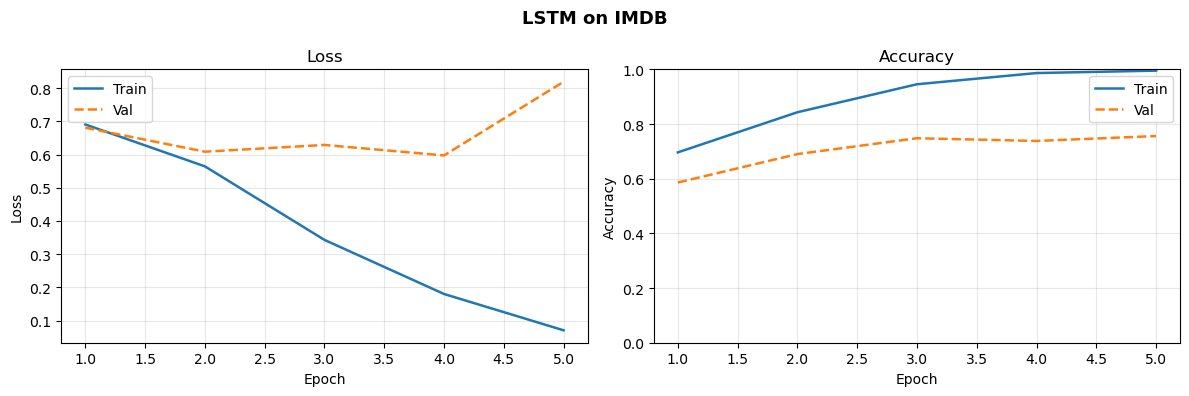

In [28]:
fig = plot_training_history(history, title="LSTM on IMDB")
os.makedirs("../assets", exist_ok=True)
fig.savefig("../assets/lstm_imdb.png", dpi=150, bbox_inches="tight")


In [29]:
y_predict = trainer.predict(X_test)
acc = np.mean(y_test == y_predict)

print(acc)

0.748


**Observation:** LSTM recovers to ~75% accuracy, a large jump over the vanilla RNN — the gating mechanism lets gradients flow across longer spans of the sequence.


### Coupled Input-Forget Gate LSTM on IMDB


In [52]:
couplstm = CoupledLSTM(
vocab_size=vocab_size,
    emb_dim=64,
    hid_dim=128,
    out_dim=2,
)

optimizer = Adam()

trainer = Trainer(
    couplstm,
    optimizer=optimizer,
    epochs=3,
    batch_size=1,
)

history = trainer.fit(
    X_train,
    y_train,
    X_val,
    y_val,
)

Epoch 1/3 | Train Loss: 0.6784 | Val Loss: 0.6143 | Train Acc: 0.7920 | Val Acc: 0.7060
Epoch 2/3 | Train Loss: 0.4745 | Val Loss: 0.4970 | Train Acc: 0.9326 | Val Acc: 0.7780
Epoch 3/3 | Train Loss: 0.2212 | Val Loss: 0.6001 | Train Acc: 0.9800 | Val Acc: 0.7880


Training curve:

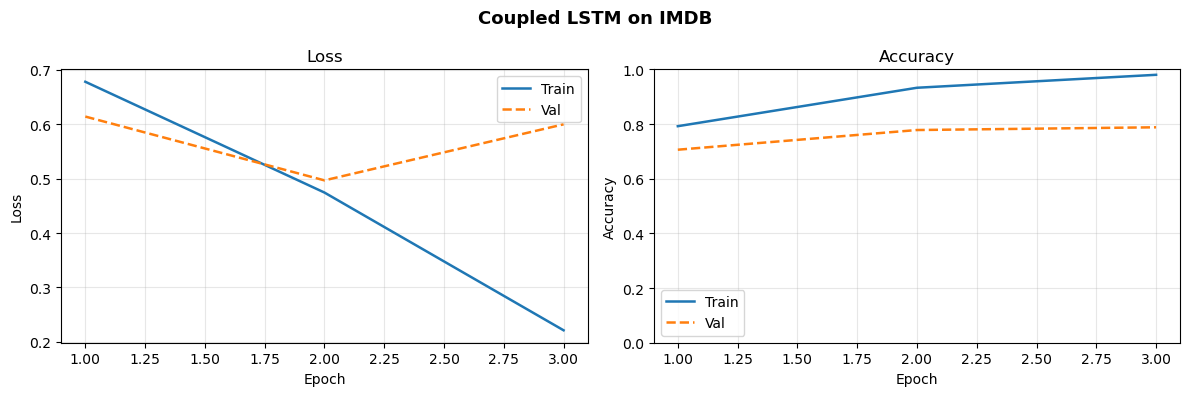

In [53]:
fig = plot_training_history(history, title="Coupled LSTM on IMDB")
os.makedirs("../assets", exist_ok=True)
fig.savefig("../assets/coupled_lstm_imdb.png", dpi=150, bbox_inches="tight")


In [54]:
y_predict = trainer.predict(X_test)
acc = np.mean(y_test == y_predict)

print(acc)

0.8552


**Observation:** the coupled-gate LSTM reaches the best result of the three (~80%), while using fewer parameters than a standard LSTM (input and forget gates share weights). This mirrors that coupling the input/forget gate rarely hurts and can help on smaller datasets.


## 6. Summary

| Architecture   | Dataset            | Test Accuracy |
|----------------|---------------------|---------------:|
| MLP            | MNIST               | 97.94%         |
| CNN            | MNIST               | 98.24%         |
| RNN            | Synthetic sequence  | 100.0%         |
| LSTM           | Synthetic sequence  | 100.0%         |
| Coupled LSTM   | Synthetic sequence  | 100.0%         |
| RNN            | IMDB                | 57.44%         |
| LSTM           | IMDB                | 74.80%         |
| Coupled LSTM   | IMDB                | **85.52%**     |

**Takeaway:** on easy/synthetic data all recurrent variants look equivalent, but on a real-world task (IMDB) the gap between vanilla RNN and gated architectures is dramatic, and gate-coupling gives a further edge over the standard LSTM.
